Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
grocery = pd.read_csv(r"D:\Vardhan's Workspace\Data Analysis Projects\Grocery Store Sales\grocery_chain_data.csv")
grocery.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2.0,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1.0,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4.0,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3.0,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5.0,8.66,43.30,1.50,41.80,22


Understand the data

In [3]:
grocery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   float64
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 170.3+ KB


In [4]:
grocery.describe()

,customer_id,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
count,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000
mean,5542.958081,2.968182,15.488045,45.902576,4.469591,41.432985,255.147980
std,2575.771856,1.419028,8.400823,35.018599,4.962001,32.593328,146.009333
min,1006.000000,1.000000,0.990000,1.010000,0.000000,-3.430000,0.000000
25%,3271.500000,2.000000,8.240000,18.000000,1.240000,15.800000,128.000000
50%,5582.500000,3.000000,15.190000,37.130000,3.045000,32.820000,265.500000
75%,7791.750000,4.000000,22.862500,67.930000,5.402500,60.800000,378.000000
max,9998.000000,5.000000,29.980000,149.900000,29.940000,147.910000,500.000000


In [5]:
grocery.isnull().sum()

customer_id          0
store_name          25
transaction_date     0
aisle                0
product_name         0
quantity             0
unit_price           0
total_amount         0
discount_amount      0
final_amount         0
loyalty_points       0
dtype: int64

Data Cleaning

In [6]:
grocery["transaction_date"] = pd.to_datetime(grocery["transaction_date"])

In [7]:
grocery = grocery[grocery["final_amount"] >= 0]

In [11]:
grocery["month"] = grocery["transaction_date"].dt.month
grocery["year"] = grocery["transaction_date"].dt.year
grocery["DayOfWeek"] = grocery["transaction_date"].dt.day_name()

grocery["profit"] = grocery["final_amount"] - grocery["discount_amount"]

grocery.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points,month,year,DayOfWeek,profit
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2.0,7.46,14.92,0.00,14.92,377,8,2023,Saturday,14.92
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4.0,7.38,29.52,4.04,25.48,301,11,2023,Thursday,21.44
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3.0,5.50,16.50,1.37,15.13,490,1,2025,Monday,13.76
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5.0,8.66,43.30,1.50,41.80,22,10,2023,Friday,40.30
5,7912,Corner Grocery,2023-08-31,Dairy,Onions,3.0,25.04,75.12,1.77,73.35,316,8,2023,Thursday,71.58


Sales Analysis

In [17]:
sales_by_store = grocery.groupby("store_name")["final_amount"].sum().sort_values(ascending= False)
print(sales_by_store)

store_name
GreenGrocer Plaza     9883.01
SuperSave Central     9861.49
City Fresh Store      9788.70
MegaMart Westside     9297.53
Corner Grocery        9286.06
ValuePlus Market      8663.57
FreshMart Downtown    8212.53
QuickStop Market      8184.16
FamilyFood Express    7719.72
Name: final_amount, dtype: float64


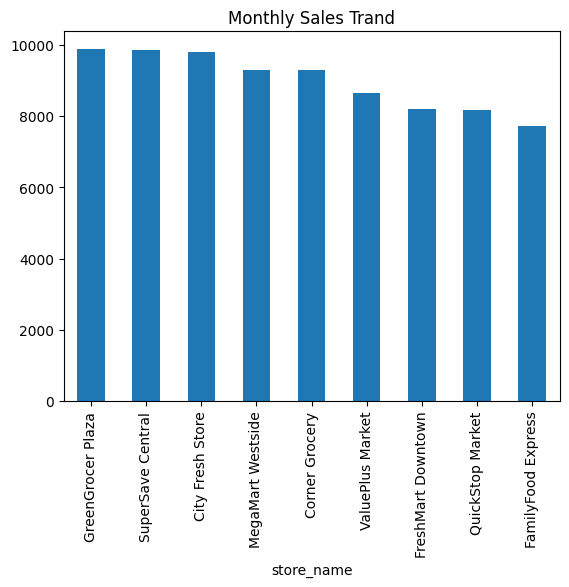

In [20]:
sales_by_store.plot(kind= 'bar')
plt.title("Monthly Sales Trand")
plt.show()

In [27]:
top_product = grocery.groupby("product_name")["quantity"].sum().sort_values(ascending= False).head(10)
print(top_product)

product_name
Chicken Breast    379.0
Tomatoes          362.0
Bread             358.0
Potatoes          353.0
Onions            340.0
Salmon            336.0
Cereal            335.0
Yogurt            335.0
Eggs              333.0
Orange Juice      331.0
Name: quantity, dtype: float64


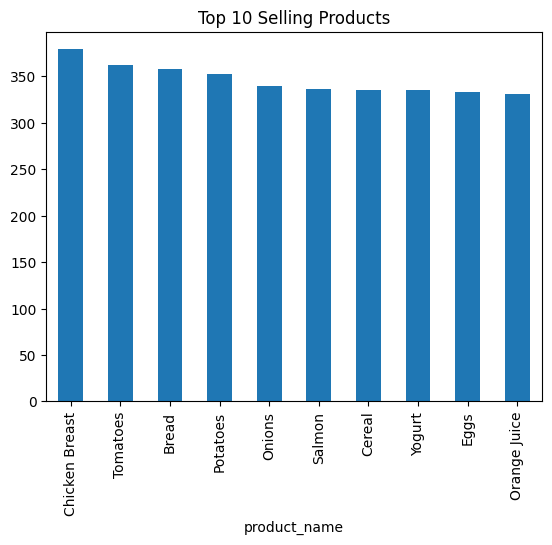

In [29]:
top_product.plot(kind= "bar")
plt.title("Top 10 Selling Products")
plt.show()

Discount Analysis

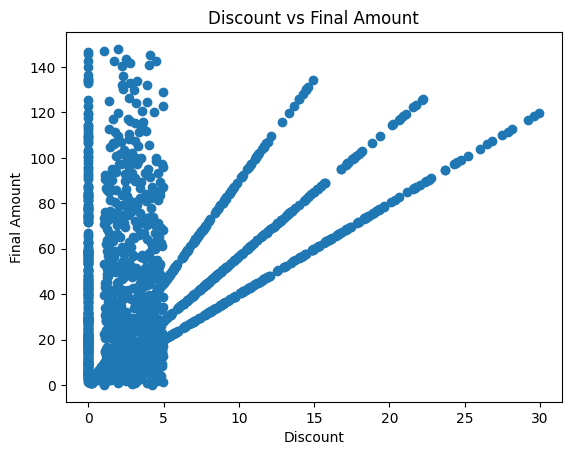

In [33]:
plt.scatter(grocery["discount_amount"], grocery["final_amount"])
plt.xlabel("Discount")
plt.ylabel("Final Amount")
plt.title("Discount vs Final Amount")
plt.show()

Customer Analysis

In [39]:
top_customers = grocery.groupby("customer_id")["final_amount"].sum().sort_values(ascending= False).head(10)
print(top_customers)

customer_id
2276    250.84
9056    239.55
8460    223.43
8381    202.60
8055    202.44
7730    201.23
9835    193.57
5272    187.75
3444    187.28
4394    183.76
Name: final_amount, dtype: float64


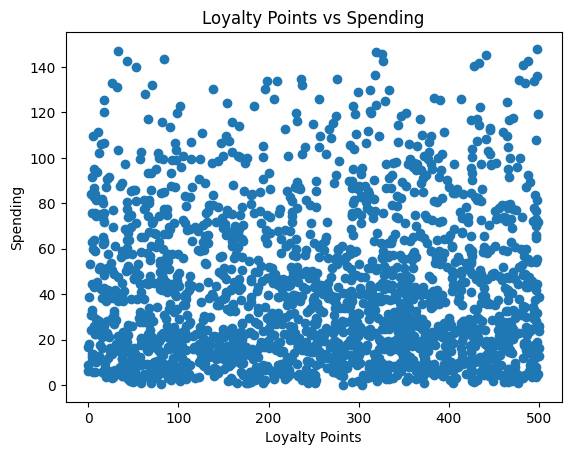

In [42]:
plt.scatter(grocery["loyalty_points"], grocery["final_amount"])
plt.xlabel("Loyalty Points")
plt.ylabel("Spending")
plt.title("Loyalty Points vs Spending")
plt.show()

RFM Customer Segmentation

In [47]:
import datetime as dt

today = grocery["transaction_date"].max()

In [51]:
rfm = grocery.groupby("customer_id").agg({
    "transaction_date": lambda x: (today - x.max()).days,
    "customer_id": "count",
    "final_amount": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]
print(rfm.head())

             Recency  Frequency  Monetary
customer_id                              
1006             493          1    109.75
1009             264          1     37.84
1018             219          1     51.91
1023             140          1     23.40
1040              55          1     43.58


In [74]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 3, labels= [3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 3, labels=[1,2,3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 3, labels=[1,2,3])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
print(rfm.head())

             Recency  Frequency  Monetary R_Score M_Score F_Score RFM_Score
customer_id                                                                
1006             493          1    109.75       1       3       1       113
1009             264          1     37.84       2       2       1       212
1018             219          1     51.91       3       2       1       312
1023             140          1     23.40       3       2       1       312
1040              55          1     43.58       3       2       1       312


Export Clean Data

In [75]:
grocery.to_csv("clean_grocery_data.csv", index= False)
rfm.to_csv("customer_rfm.csv")